# 04 — Trening attention modela (M1: ELU, M2: ReLU)

Treniramo c-ResUnet **sa attention gate-ovima** (Oktay et al. 2018) na skip vezama.
Dva modela:
- **M1:** attention + ELU aktivacija
- **M2:** attention + ReLU aktivacija

Poredimo ih međusobno i sa M0 baseline-om iz sveske 03.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

from src import config
from src.data_loading import make_dataset
from src.models import build_model
from src.train import (
    get_device, train_model, find_best_threshold,
    save_model, save_predictions, count_parameters,
)
import time

## 1. Podaci i device

In [2]:
device = get_device()
print(f"Device: {device}")

train_ds = make_dataset(split="train", form="crops", augment=True)
val_ds   = make_dataset(split="val",   form="full",  augment=False)
test_ds  = make_dataset(split="test",  form="full",  augment=False)

BATCH_SIZE = config.BATCH_SIZE_ATTENTION
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=1,          shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=1,          shuffle=False, num_workers=0)

print(f"Train: {len(train_ds)} crop-ova, batch={BATCH_SIZE}")
print(f"Val:   {len(val_ds)} celih slika")
print(f"Test:  {len(test_ds)} celih slika")

Device: mps
Train: 2040 crop-ova, batch=4
Val:   43 celih slika
Test:  70 celih slika


---
## 2. Model M1 — c-ResUnet + Attention (ELU)

In [3]:
model_m1 = build_model(attention=True, activation="elu")
model_m1 = model_m1.to(device)
print("=== M1: Attention + ELU ===")
count_parameters(model_m1)

=== M1: Attention + ELU ===
  init_conv: 48 parametara
  enc1: 4,672 parametara
  enc1_5x5: 6,432 parametara
  pool1: 0 parametara
  enc2: 14,432 parametara
  pool2: 0 parametara
  enc3: 57,536 parametara
  pool3: 0 parametara
  bottleneck: 229,760 parametara
  up3: 32,768 parametara
  dec3: 119,168 parametara
  up2: 8,192 parametara
  dec2: 29,888 parametara
  up1: 2,048 parametara
  dec1: 7,520 parametara
  out_conv: 17 parametara
  ag3: 4,258 parametara
  ag2: 1,106 parametara
  ag1: 298 parametara
  UKUPNO: 518,143


518143

In [4]:
t0 = time.time()
model_m1, metrics_m1 = train_model(
    model_m1, train_loader, val_loader,
    num_epochs=config.NUM_EPOCHS,
    lr=config.LEARNING_RATE,
    device=device,
)
print(f"Obučavanje modela trajalo: {time.time()-t0:.1f}s")

Trening:   0%|          | 0/100 [00:00<?, ?it/s]


Early stopping na epohi 55 (best = ep 35, val_loss = 0.0097)
Najbolja epoha: 35, val_loss: 0.0097
Obučavanje modela trajalo: 6318.1s


In [5]:
best_thresh_m1, thresh_results_m1 = find_best_threshold(model_m1, val_loader, device=device)

Najbolji threshold: 0.65 (piksel F1 = 0.6426)


In [6]:
save_model(model_m1, "M1_attention_elu", best_thresh_m1)
save_predictions(model_m1, test_loader, "M1_attention_elu", device=device)

Model sačuvan: /Users/ana_velimirovic/Desktop/Ana-priv/ML/projekat/Fluorescent-neuronal-cell-counting/models/M1_attention_elu.pth (threshold=0.6500)


Predikcije:   0%|          | 0/70 [00:00<?, ?it/s]

Predikcije sačuvane u /Users/ana_velimirovic/Desktop/Ana-priv/ML/projekat/Fluorescent-neuronal-cell-counting/preds/M1_attention_elu (70 slika)


---
## 3. Model M2 — c-ResUnet + Attention (ReLU)

Isti attention model, ali sa ReLU umesto ELU.
ReLU može uzrokovati "mrtve neurone" (Tashfeen, §3.1) — ovo je kontrolni eksperiment.

In [7]:
# Ponovo kreiraj train_loader za svež augment
train_ds_m2 = make_dataset(split="train", form="crops", augment=True)
train_loader_m2 = DataLoader(train_ds_m2, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

model_m2 = build_model(attention=True, activation="relu")
model_m2 = model_m2.to(device)
print("=== M2: Attention + ReLU ===")
count_parameters(model_m2)

=== M2: Attention + ReLU ===
  init_conv: 48 parametara
  enc1: 4,672 parametara
  enc1_5x5: 6,432 parametara
  pool1: 0 parametara
  enc2: 14,432 parametara
  pool2: 0 parametara
  enc3: 57,536 parametara
  pool3: 0 parametara
  bottleneck: 229,760 parametara
  up3: 32,768 parametara
  dec3: 119,168 parametara
  up2: 8,192 parametara
  dec2: 29,888 parametara
  up1: 2,048 parametara
  dec1: 7,520 parametara
  out_conv: 17 parametara
  ag3: 4,258 parametara
  ag2: 1,106 parametara
  ag1: 298 parametara
  UKUPNO: 518,143


518143

In [8]:
t0 = time.time()
model_m2, metrics_m2 = train_model(
    model_m2, train_loader_m2, val_loader,
    num_epochs=config.NUM_EPOCHS,
    lr=config.LEARNING_RATE,
    device=device,
)
print(f"Obučavanje modela trajalo: {time.time()-t0:.1f}s")

Trening:   0%|          | 0/100 [00:00<?, ?it/s]


Early stopping na epohi 66 (best = ep 46, val_loss = 0.0093)
Najbolja epoha: 46, val_loss: 0.0093
Obučavanje modela trajalo: 7340.1s


In [9]:
best_thresh_m2, thresh_results_m2 = find_best_threshold(model_m2, val_loader, device=device)

Najbolji threshold: 0.60 (piksel F1 = 0.6584)


In [10]:
save_model(model_m2, "M2_attention_relu", best_thresh_m2)
save_predictions(model_m2, test_loader, "M2_attention_relu", device=device)

Model sačuvan: /Users/ana_velimirovic/Desktop/Ana-priv/ML/projekat/Fluorescent-neuronal-cell-counting/models/M2_attention_relu.pth (threshold=0.6000)


Predikcije:   0%|          | 0/70 [00:00<?, ?it/s]

Predikcije sačuvane u /Users/ana_velimirovic/Desktop/Ana-priv/ML/projekat/Fluorescent-neuronal-cell-counting/preds/M2_attention_relu (70 slika)


---
## 4. Poređenje M1 vs M2

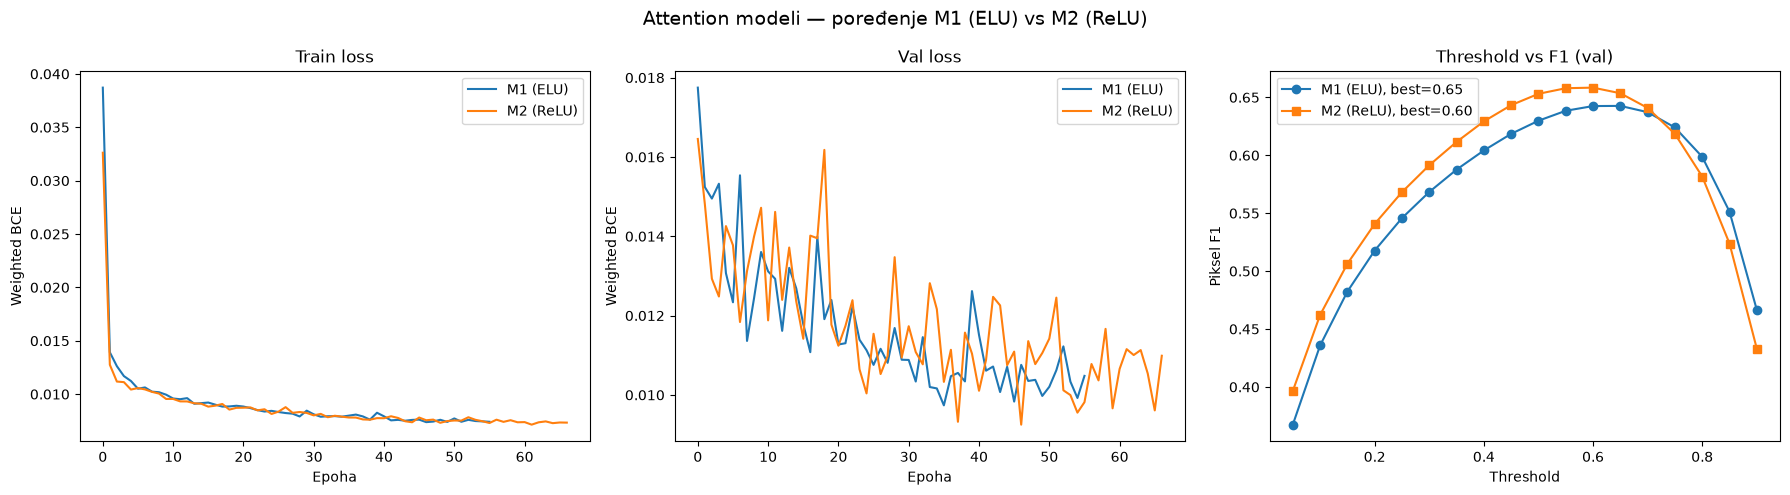

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Train loss
axes[0].plot(metrics_m1["epoch"], metrics_m1["train_loss"], label="M1 (ELU)")
axes[0].plot(metrics_m2["epoch"], metrics_m2["train_loss"], label="M2 (ReLU)")
axes[0].set_xlabel("Epoha")
axes[0].set_ylabel("Weighted BCE")
axes[0].set_title("Train loss")
axes[0].legend()

# Val loss
axes[1].plot(metrics_m1["epoch"], metrics_m1["val_loss"], label="M1 (ELU)")
axes[1].plot(metrics_m2["epoch"], metrics_m2["val_loss"], label="M2 (ReLU)")
axes[1].set_xlabel("Epoha")
axes[1].set_ylabel("Weighted BCE")
axes[1].set_title("Val loss")
axes[1].legend()

# Threshold krive
ts1, f1s1 = zip(*thresh_results_m1)
ts2, f1s2 = zip(*thresh_results_m2)
axes[2].plot(ts1, f1s1, marker='o', label=f"M1 (ELU), best={best_thresh_m1:.2f}")
axes[2].plot(ts2, f1s2, marker='s', label=f"M2 (ReLU), best={best_thresh_m2:.2f}")
axes[2].set_xlabel("Threshold")
axes[2].set_ylabel("Piksel F1")
axes[2].set_title("Threshold vs F1 (val)")
axes[2].legend()

plt.suptitle("Attention modeli — poređenje M1 (ELU) vs M2 (ReLU)", fontsize=14)
plt.tight_layout()
plt.show()

## 5. Kvalitativni pregled — iste test slike za oba modela

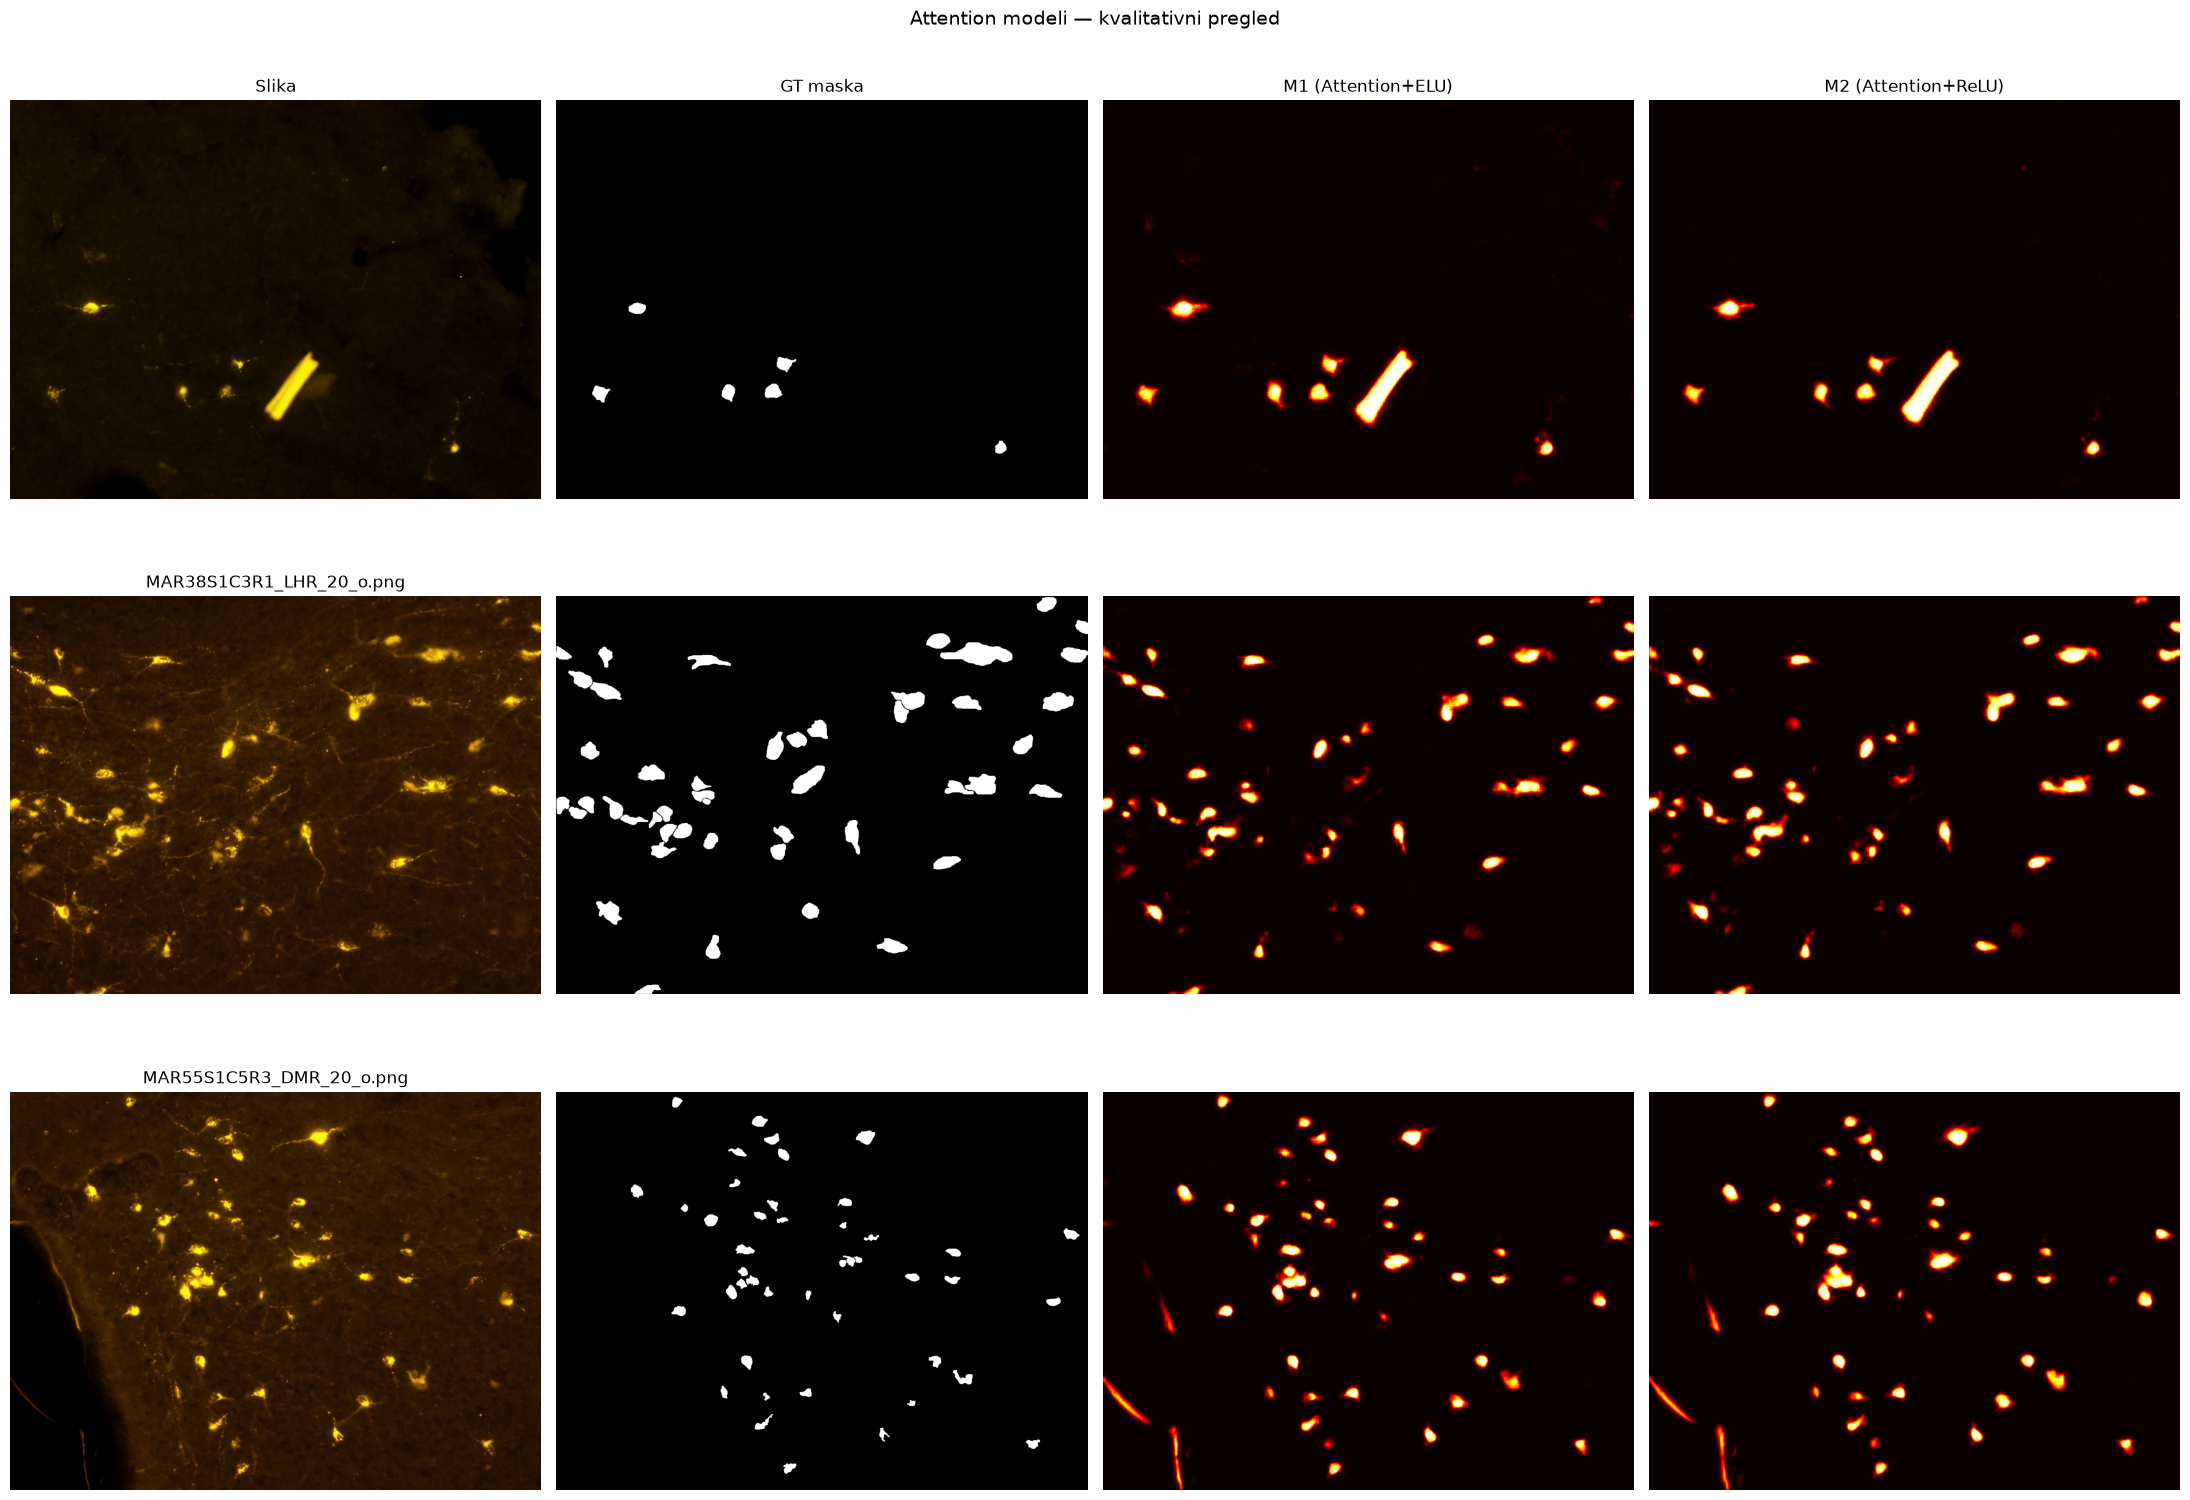

In [12]:
model_m1.eval()
model_m2.eval()

fig, axes = plt.subplots(3, 4, figsize=(22, 16))
col_titles = ["Slika", "GT maska", "M1 (Attention+ELU)", "M2 (Attention+ReLU)"]

sample_iter = iter(test_loader)
for row in range(3):
    img, mask, iid = next(sample_iter)
    with torch.no_grad():
        pred_m1 = model_m1(img.to(device)).cpu()
        pred_m2 = model_m2(img.to(device)).cpu()

    axes[row, 0].imshow(img[0].permute(1, 2, 0).numpy())
    axes[row, 0].set_title(f"{iid[0]}" if row == 0 else iid[0])

    axes[row, 1].imshow(mask[0, 0].numpy(), cmap="gray")

    axes[row, 2].imshow(pred_m1[0, 0].numpy(), cmap="hot", vmin=0, vmax=1)

    axes[row, 3].imshow(pred_m2[0, 0].numpy(), cmap="hot", vmin=0, vmax=1)

for j, t in enumerate(col_titles):
    axes[0, j].set_title(t, fontsize=12)

for ax in axes.flat:
    ax.axis("off")

plt.suptitle("Attention modeli — kvalitativni pregled", fontsize=14)
plt.tight_layout()
plt.show()